# 01 – Data Exploration

This notebook explores sensor measurements from a hydraulic test rig.

## Objectives

- Understand how the measurement data is organized.
- Load sensor signals and component condition labels separately.
- Visualize a temperature signal within one operating cycle.

## Dataset structure

Each row represents one 60-second operating cycle.
Columns in a sensor file represent measurements within that cycle.
The corresponding row in `profile.txt` describes the component conditions.

## Source

[Helwig, Pignanelli & Schütze (2015),
Condition monitoring of hydraulic systems, UCI Machine Learning Repository](https://doi.org/10.24432/C5CW21).

Dataset license: CC BY 4.0.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import maintenance_copilot

# Locate the project root through our installed Python package.
PROJECT_ROOT = Path(maintenance_copilot.__file__).resolve().parents[2]
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "hydraulic"

# Component condition labels: one row per operating cycle.
profile = pd.read_csv(
    DATA_DIR / "profile.txt",
    sep=r"\s+",
    header=None,
    names=[
        "cooler_condition_pct",
        "valve_condition_pct",
        "pump_leakage",
        "accumulator_pressure_bar",
        "stability_flag",
    ],
)

# Temperature sensor TS1: one row per operating cycle.
temperature = pd.read_csv(
    DATA_DIR / "TS1.txt",
    sep=r"\s+",
    header=None,
    dtype=np.float32,
).to_numpy()

print("Project root:", PROJECT_ROOT)
print("Condition labels:", profile.shape)
print("Temperature measurements:", temperature.shape)

profile.head()

Project root: /Users/alexanderkorolev/Projekte/industrial-maintenance-copilot
Condition labels: (2205, 5)
Temperature measurements: (2205, 60)


,cooler_condition_pct,valve_condition_pct,pump_leakage,accumulator_pressure_bar,stability_flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


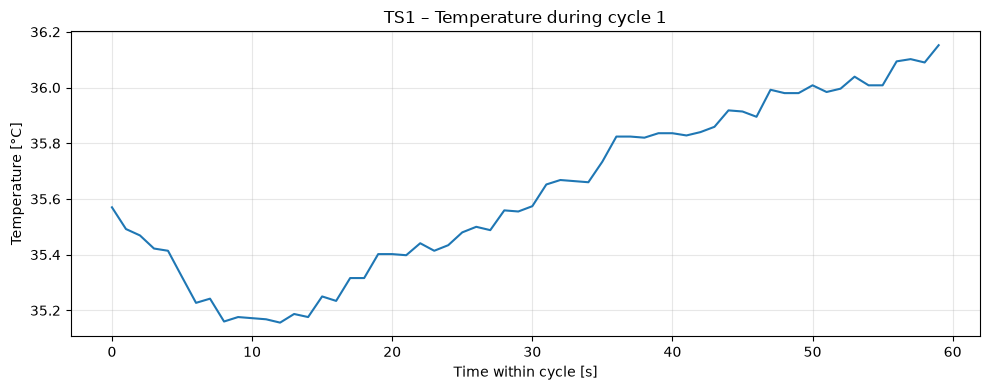

In [2]:
cycle_idx = 0

# TS1 records one measurement per second.
time_s = np.arange(temperature.shape[1])

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    time_s,
    temperature[cycle_idx],
    color="tab:blue",
)

ax.set(
    title=f"TS1 – Temperature during cycle {cycle_idx + 1}",
    xlabel="Time within cycle [s]",
    ylabel="Temperature [°C]",
)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Component Conditions and Healthy Reference

We define a healthy reference cycle as a cycle in which all four
components have their nominal condition values and the test conditions
are stable.

| Label | Required value | Meaning |
|---|---:|---|
| `cooler_condition_pct` | 100 | Full cooling efficiency |
| `valve_condition_pct` | 100 | Optimal switching behavior |
| `pump_leakage` | 0 | No internal pump leakage |
| `accumulator_pressure_bar` | 130 | Optimal accumulator pressure |
| `stability_flag` | 0 | Stable test conditions |

We separate the cycles into three groups:

- **healthy_stable:** All components are nominal and conditions are stable.
- **degraded_stable:** At least one component is degraded and conditions are stable.
- **stability_not_confirmed:** Conditions may not yet have reached a steady state.
  This group may contain both nominal and degraded component settings.

Component labels support reference selection and model evaluation.
Model input features will be calculated exclusively from sensor signals.

Training, validation, and test partitions will be defined before fitting
any preprocessing steps or models.

In [3]:
allowed_values = {
    "cooler_condition_pct": {3, 20, 100},
    "valve_condition_pct": {73, 80, 90, 100},
    "pump_leakage": {0, 1, 2},
    "accumulator_pressure_bar": {90, 100, 115, 130},
    "stability_flag": {0, 1},
}

distribution_tables = []

for column, valid_values in allowed_values.items():
    if not profile[column].isin(valid_values).all():
        raise ValueError(
            f"Unexpected or missing condition labels in '{column}'."
        )

    counts = profile[column].value_counts().sort_index()

    distribution_tables.append(
        pd.DataFrame(
            {
                "label": column,
                "value": counts.index,
                "cycle_count": counts.to_numpy(),
            }
        )
    )

label_distribution = pd.concat(
    distribution_tables,
    ignore_index=True,
)

label_distribution

,label,value,cycle_count
0,cooler_condition_pct,3,732
1,cooler_condition_pct,20,732
2,cooler_condition_pct,100,741
3,valve_condition_pct,73,360
4,valve_condition_pct,80,360
5,valve_condition_pct,90,360
6,valve_condition_pct,100,1125
7,pump_leakage,0,1221
8,pump_leakage,1,492
9,pump_leakage,2,492


In [4]:
HEALTHY_CONDITIONS = {
    "cooler_condition_pct": 100,
    "valve_condition_pct": 100,
    "pump_leakage": 0,
    "accumulator_pressure_bar": 130,
}

# Check whether all four components have nominal condition values.
nominal_components = (
    profile[list(HEALTHY_CONDITIONS)]
    .eq(pd.Series(HEALTHY_CONDITIONS), axis="columns")
    .all(axis=1)
)

# Stability is evaluated separately from component condition.
stable_conditions = profile["stability_flag"].eq(0)

# Boolean masks preserve the original cycle order.
healthy_mask = nominal_components & stable_conditions
degraded_mask = ~nominal_components & stable_conditions
unconfirmed_stability_mask = ~stable_conditions

cohort_summary = pd.DataFrame(
    {
        "cohort": [
            "healthy_stable",
            "degraded_stable",
            "stability_not_confirmed",
        ],
        "cycle_count": [
            int(healthy_mask.sum()),
            int(degraded_mask.sum()),
            int(unconfirmed_stability_mask.sum()),
        ],
    }
)

cohort_summary["share_pct"] = (
    100 * cohort_summary["cycle_count"] / len(profile)
).round(2)

cohort_summary

,cohort,cycle_count,share_pct
0,healthy_stable,10,0.45
1,degraded_stable,1439,65.26
2,stability_not_confirmed,756,34.29


## Component-Level Coverage and Cooler Comparison

Only 10 of the 2,205 cycles meet our strict definition of a fully
nominal, stable system. This provides very limited data for training
and independently evaluating a system-wide normal-only detector.

We therefore examine the available reference data for each component
separately.

A nominal component label describes that component only. Other
components may still be degraded during the same cycle.

Our first signal comparison examines temperature sensor TS1 across
the three cooler conditions, using stable cycles.

Lines show the median temperature at each time point. Shaded bands
show the 25th–75th percentile range across cycles.

These comparisons describe associations in the recorded test data.
Other component conditions may also influence the measurements.

In [5]:
coverage_rows = []

for column, nominal_value in HEALTHY_CONDITIONS.items():
    component_nominal = profile[column].eq(nominal_value)

    coverage_rows.append(
        {
            "component": column,
            "nominal_value": nominal_value,
            "nominal_stable_cycles": int(
                (stable_conditions & component_nominal).sum()
            ),
            "degraded_stable_cycles": int(
                (stable_conditions & ~component_nominal).sum()
            ),
        }
    )

component_coverage = pd.DataFrame(coverage_rows).set_index("component")

component_coverage

,nominal_value,nominal_stable_cycles,degraded_stable_cycles
component,,,
cooler_condition_pct,100,489,960
valve_condition_pct,100,369,1080
pump_leakage,0,489,960
accumulator_pressure_bar,130,360,1089


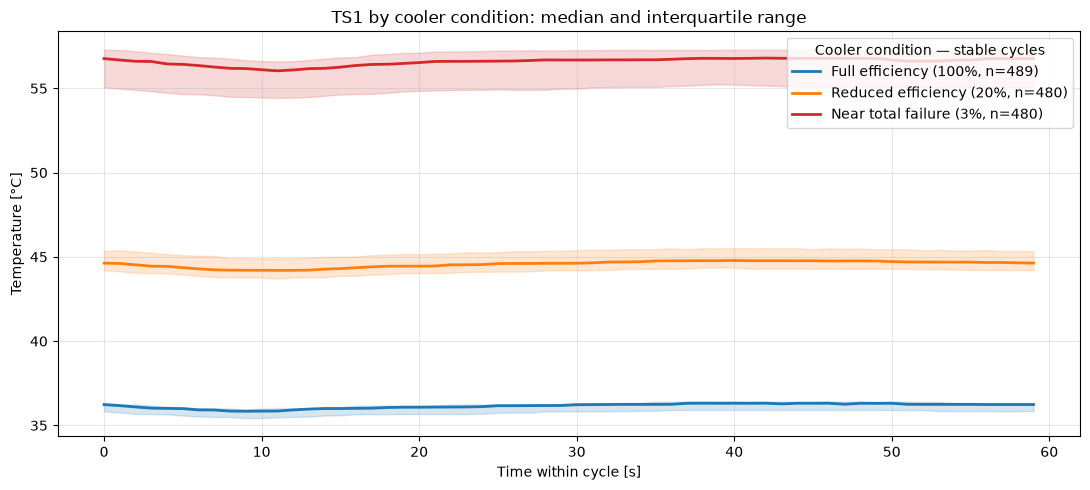

Saved figure: /Users/alexanderkorolev/Projekte/industrial-maintenance-copilot/reports/figures/cooler_temperature_comparison.png


In [6]:
cooler_groups = [
    (100, "Full efficiency", "tab:blue"),
    (20, "Reduced efficiency", "tab:orange"),
    (3, "Near total failure", "tab:red"),
]

# TS1 has a sampling rate of 1 Hz.
time_s = np.arange(temperature.shape[1])

fig, ax = plt.subplots(figsize=(11, 5))

for condition, label, color in cooler_groups:
    group_mask = (
        stable_conditions
        & profile["cooler_condition_pct"].eq(condition)
    ).to_numpy(dtype=bool)

    group_signals = temperature[group_mask]

    if group_signals.shape[0] == 0:
        continue

    # Summarize variation across cycles at each time point.
    lower, median, upper = np.percentile(
        group_signals,
        [25, 50, 75],
        axis=0,
    )

    ax.plot(
        time_s,
        median,
        color=color,
        linewidth=2,
        label=f"{label} ({condition}%, n={group_signals.shape[0]})",
    )

    ax.fill_between(
        time_s,
        lower,
        upper,
        color=color,
        alpha=0.18,
    )

ax.set(
    title="TS1 by cooler condition: median and interquartile range",
    xlabel="Time within cycle [s]",
    ylabel="Temperature [°C]",
)
ax.legend(title="Cooler condition — stable cycles")
ax.grid(alpha=0.3)

fig.tight_layout()

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

figure_path = FIGURE_DIR / "cooler_temperature_comparison.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")

plt.show()

print(f"Saved figure: {figure_path}")

## Data Quality: Temperature Sensors

We extend the exploration to temperature sensors TS1, TS2, TS3, and TS4.

Each sensor file contains one row per operating cycle and 60 measurements
per row, sampled at 1 Hz.

Before extracting features, we check:

- The number of cycles matches the condition labels.
- Each cycle contains exactly 60 samples.
- All measurements are finite.

Invalid measurements stop the analysis rather than being silently replaced.

In [7]:
TEMPERATURE_SENSORS = ("TS1", "TS2", "TS3", "TS4")
SAMPLE_RATE_HZ = 1.0
EXPECTED_SAMPLES = 60

temperature_signals = {}
quality_rows = []

for sensor in TEMPERATURE_SENSORS:
    values = pd.read_csv(
        DATA_DIR / f"{sensor}.txt",
        sep=r"\s+",
        header=None,
        dtype=np.float64,
    ).to_numpy()

    if values.shape != (len(profile), EXPECTED_SAMPLES):
        raise ValueError(f"Unexpected shape for {sensor}: {values.shape}")

    if not np.isfinite(values).all():
        raise ValueError(f"Missing or infinite measurements in {sensor}.")

    temperature_signals[sensor] = values

    quality_rows.append(
        {
            "sensor": sensor,
            "cycles": values.shape[0],
            "samples_per_cycle": values.shape[1],
            "missing_values": int(np.isnan(values).sum()),
            "min_temperature_c": float(values.min()),
            "max_temperature_c": float(values.max()),
        }
    )

sensor_quality = pd.DataFrame(quality_rows).set_index("sensor")
sensor_quality.round(2)

,cycles,samples_per_cycle,missing_values,min_temperature_c,max_temperature_c
sensor,,,,,
TS1,2205,60,0,34.98,58.21
TS2,2205,60,0,40.71,62.18
TS3,2205,60,0,38.15,59.54
TS4,2205,60,0,30.36,53.14


## Per-Cycle Temperature Features

We summarize each sensor signal using six features:

| Feature | Description | Unit |
|---|---|---|
| Mean | Average temperature within the cycle | °C |
| Standard deviation | Within-cycle variation, using `ddof=0` | °C |
| Minimum | Lowest recorded temperature | °C |
| Maximum | Highest recorded temperature | °C |
| Range | Maximum minus minimum | °C |
| Slope | Least-squares linear temperature trend over time | °C/s |

Four sensors produce 24 features per operating cycle.

Features are calculated independently for each cycle. This step does
not estimate parameters across cycles.

Component labels, stability flags, and cycle identifiers are excluded
from the feature matrix. Any learned preprocessing will be fitted
using training data only.

These features describe complete cycles and therefore become available
after the corresponding cycle has finished.

In [8]:
from maintenance_copilot.features import extract_temperature_features

temperature_features = extract_temperature_features(
    temperature_signals
)

temperature_features.index = profile.index

print("Feature matrix shape:", temperature_features.shape)

temperature_features.head()

Feature matrix shape: (2205, 24)


,TS1__mean,TS1__std,TS1__min,TS1__max,TS1__range,TS1__slope,TS2__mean,TS2__std,TS2__min,TS2__max,...,TS3__min,TS3__max,TS3__range,TS3__slope,TS4__mean,TS4__std,TS4__min,TS4__max,TS4__range,TS4__slope
0,35.621983,0.305650,35.156,36.152,0.996,0.016270,40.978767,0.153010,40.773,41.250,...,38.316,38.613,0.297,0.003956,31.745250,1.107135,30.363,33.594,3.231,0.063211
1,36.676967,0.580839,35.648,37.488,1.840,0.032236,41.532767,0.335404,41.031,42.105,...,38.668,39.254,0.586,0.009737,34.493867,0.431670,33.648,35.148,1.500,0.024709
2,37.880800,0.554490,36.879,38.621,1.742,0.029980,42.442450,0.387320,41.832,43.039,...,39.234,40.062,0.828,0.014040,35.646150,0.291430,35.098,36.141,1.043,0.016711
3,38.879050,0.511856,37.887,39.473,1.586,0.027020,43.403983,0.395141,42.805,43.988,...,40.023,40.934,0.911,0.015759,36.579467,0.260201,36.105,36.988,0.883,0.014897
4,39.803917,0.530893,38.789,40.391,1.602,0.028058,44.332750,0.369649,43.742,44.887,...,40.859,41.777,0.918,0.016441,37.427900,0.237566,36.992,37.781,0.789,0.013597


## Temperature Features by Cooler Condition

We compare cycle mean temperatures across the three cooler conditions,
using stable cycles only.

The summary table reports the median of the cycle means for each sensor.

The boxplots show:

- The median as a line inside each box.
- The 25th–75th percentile range as the box.
- Whiskers extending to observations within 1.5 interquartile ranges.
- Any observations beyond the whiskers as individual points.

These plots describe associations in the recorded data. Other component
conditions may also influence the temperatures.

Boxplot outliers are descriptive observations, not model-generated
anomaly alerts.

In [9]:
cooler_feature_rows = []

for condition, label, _ in cooler_groups:
    mask = stable_conditions & profile["cooler_condition_pct"].eq(condition)
    group = temperature_features.loc[mask]

    row = {
        "cooler_condition_pct": condition,
        "condition": label,
        "stable_cycles": len(group),
    }

    for sensor in TEMPERATURE_SENSORS:
        row[f"{sensor}_median_cycle_mean_c"] = (
            group[f"{sensor}__mean"].median()
        )

    cooler_feature_rows.append(row)

cooler_feature_summary = pd.DataFrame(cooler_feature_rows)
cooler_feature_summary.round(2)

,cooler_condition_pct,condition,stable_cycles,TS1_median_cycle_mean_c,TS2_median_cycle_mean_c,TS3_median_cycle_mean_c,TS4_median_cycle_mean_c
0,100,Full efficiency,489,36.16,41.79,39.03,31.14
1,20,Reduced efficiency,480,44.57,49.60,46.82,40.06
2,3,Near total failure,480,56.58,60.48,58.19,52.03


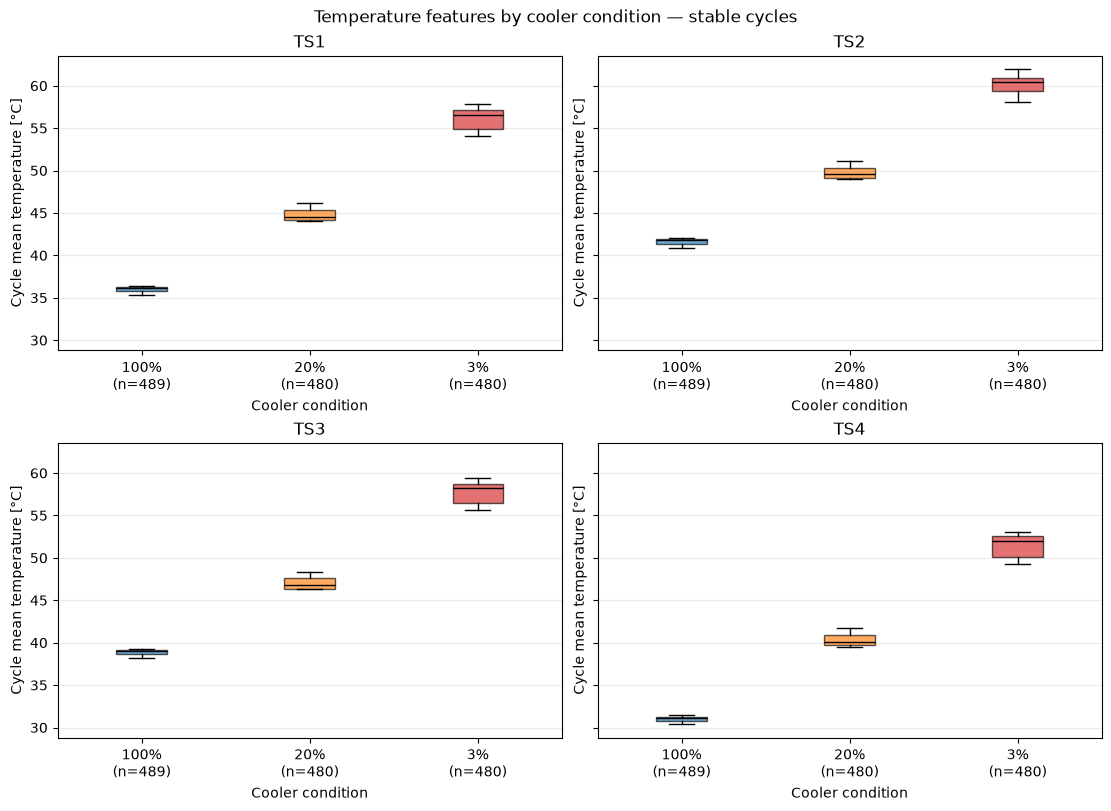

Saved figure: reports/figures/cooler_temperature_features.png


In [10]:
fig, axes = plt.subplots(
    2, 2, figsize=(11, 8), sharey=True, constrained_layout=True
)

for ax, sensor in zip(axes.flat, TEMPERATURE_SENSORS, strict=True):
    group_values = []
    tick_labels = []

    for condition, _, _ in cooler_groups:
        mask = (
            stable_conditions
            & profile["cooler_condition_pct"].eq(condition)
        )

        values = temperature_features.loc[
            mask, f"{sensor}__mean"
        ].to_numpy()

        group_values.append(values)
        tick_labels.append(f"{condition}%\n(n={len(values)})")

    boxes = ax.boxplot(
        group_values,
        tick_labels=tick_labels,
        patch_artist=True,
        showfliers=True,
        medianprops={"color": "black"},
        flierprops={"marker": ".", "markersize": 3, "alpha": 0.4},
    )

    for box, (_, _, color) in zip(
        boxes["boxes"], cooler_groups, strict=True
    ):
        box.set_facecolor(color)
        box.set_alpha(0.65)

    ax.set(
        title=sensor,
        xlabel="Cooler condition",
        ylabel="Cycle mean temperature [°C]",
    )
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Temperature features by cooler condition — stable cycles"
)

feature_figure_path = FIGURE_DIR / "cooler_temperature_features.png"

fig.savefig(
    feature_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:", feature_figure_path.relative_to(PROJECT_ROOT))

## Evaluation Groups and Data Export

Multiple cycles share the same combination of cooler, valve, pump,
and accumulator conditions.

We count these combinations to prepare a grouped evaluation. All cycles
with the same four-component condition combination should remain in
one partition.

This avoids sharing identical condition combinations between training,
validation, and test partitions. It does not establish independence
between machines or prove generalization to future operating periods.

Condition labels will support partitioning, reference selection, and
evaluation. They will not become model input features.

We export:

- Sensor features and condition labels as separate files.
- Matching cycle IDs based on the original one-based file row numbers.
- Summary tables for documenting the exploration.

The cycle ID is an alignment key, not a predictive feature.

In [11]:
condition_columns = list(HEALTHY_CONDITIONS)

condition_groups = (
    profile.loc[stable_conditions]
    .groupby(condition_columns, sort=True)
    .size()
    .rename("cycle_count")
    .reset_index()
)

condition_group_summary = (
    condition_groups.groupby("cooler_condition_pct")
    .agg(
        condition_groups=("cycle_count", "size"),
        stable_cycles=("cycle_count", "sum"),
        min_cycles_per_group=("cycle_count", "min"),
        max_cycles_per_group=("cycle_count", "max"),
    )
    .reindex([100, 20, 3])
)

print(
    "Distinct stable condition combinations:",
    len(condition_groups),
)

condition_group_summary

Distinct stable condition combinations: 144


,condition_groups,stable_cycles,min_cycles_per_group,max_cycles_per_group
cooler_condition_pct,,,,
100,48,489,10,19
20,48,480,10,10
3,48,480,10,10


In [12]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Use the original one-based file row number as the exported cycle ID.
cycle_ids = pd.RangeIndex(
    1,
    len(profile) + 1,
    name="cycle_id",
)

temperature_features.set_axis(cycle_ids).to_csv(
    PROCESSED_DIR / "temperature_features.csv"
)

profile.set_axis(cycle_ids).to_csv(
    PROCESSED_DIR / "cycle_labels.csv"
)

sensor_quality.to_csv(
    TABLE_DIR / "sensor_quality.csv"
)

cohort_summary.to_csv(
    TABLE_DIR / "cohort_summary.csv",
    index=False,
)

component_coverage.to_csv(
    TABLE_DIR / "component_coverage.csv"
)

cooler_feature_summary.to_csv(
    TABLE_DIR / "cooler_feature_summary.csv",
    index=False,
)

condition_group_summary.to_csv(
    TABLE_DIR / "condition_group_summary.csv"
)

print(
    f"Saved {len(temperature_features)} cycles "
    "with 24 temperature features."
)
print(
    "Features and labels are stored in separate files "
    "under data/processed/."
)
print("Summary tables are stored under reports/tables/.")

Saved 2205 cycles with 24 temperature features.
Features and labels are stored in separate files under data/processed/.
Summary tables are stored under reports/tables/.


## Findings and Modeling Decision

### Findings

- The dataset contains 2,205 operating cycles.
- The four temperature files contain finite measurements with the
  expected dimensions.
- Only 10 cycles have nominal conditions for all four components
  and confirmed stability.
- There are 1,449 stable cycles, including 489 with a nominal cooler.
- Stable cycles cover 144 distinct component condition combinations.
- Cycle mean temperatures show clear separation between cooler
  conditions in this dataset.
- We extracted 24 temperature features per cycle.

### First modeling experiment

We will build a cooler-focused anomaly detection baseline using
stable cycles and grouped training, validation, and test partitions.

The Isolation Forest will be trained on nominal-cooler training cycles.
Other components may still be degraded in these reference cycles.

An alert threshold will be calibrated using nominal-cooler validation
cycles. We will compare the model against a simple TS1 mean-temperature
threshold.

### Interpretation limits

The full dataset has already informed this exploration. Subsequent
metrics will therefore be reported as development-benchmark results.

An anomaly score is not a calibrated failure probability. Temperature
deviations alone do not establish a physical root cause or demonstrate
performance on other machines.